In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X = np.array([[1,2,3,4,5],
             [6,7,8,9,0]])

print(X)

[[1 2 3 4 5]
 [6 7 8 9 0]]


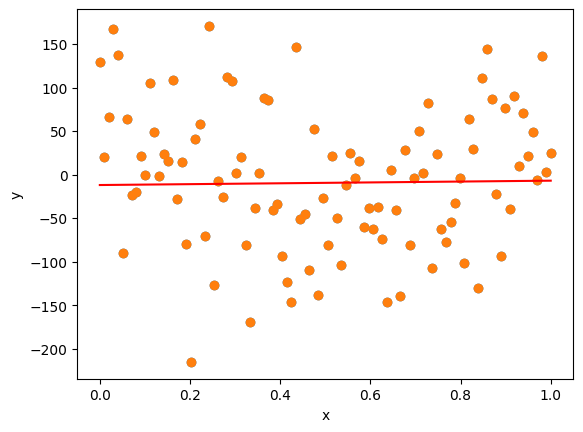

In [41]:
np.random.seed(0)
x = np.linspace(0, 1, 100)
y = 5 * x - 12
ry = np.random.normal(scale=80,size=y.shape[0]) + y
data = pd.DataFrame({'x': x, 'y':ry}).sample(frac=1).reset_index()[['index', 'y']].rename({'index':'x'}, axis=1)
plt.plot(x, ry, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x, ry, 'o')
plt.plot(x, y, 'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

The ground truth line is 
. But, let's see if our Linear Regression model can discover this. |y = 5x-12|

$$ \hat{y} = \sum_{i=1}^{n} w_i \cdot x + w_0 $$
$$ \hat{y} = w_1 \cdot x + w_0 $$



In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

x = data['x'].values.reshape((-1, 1))
y = data['y'].values.reshape((-1, 1))
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
w_1 = model.coef_
w_0 = model.intercept_

In [44]:
w_1  # هي جات 4.81 وحنا عندنا x5+6

array([[-0.18975908]])

In [45]:
w_0 # هي جات 4.67 وحنا عندنا x5-12

array([4.67771583])

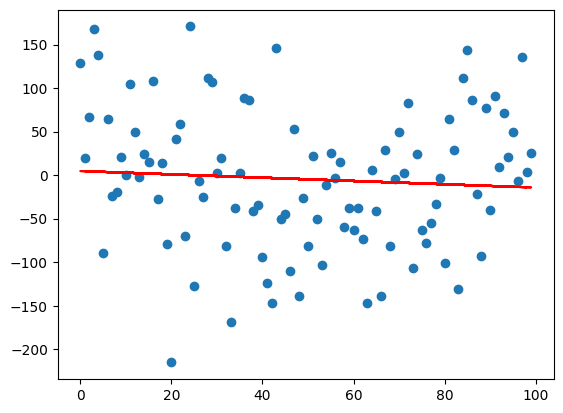

In [46]:
# الرسم المتوقع
pred_line = w_1[0,0] * x.reshape(-1)+ w_0[0]
plt.plot(x.reshape(-1), data['y'], 'o')
plt.plot(x.reshape(-1), pred_line, 'r-')
plt.show()

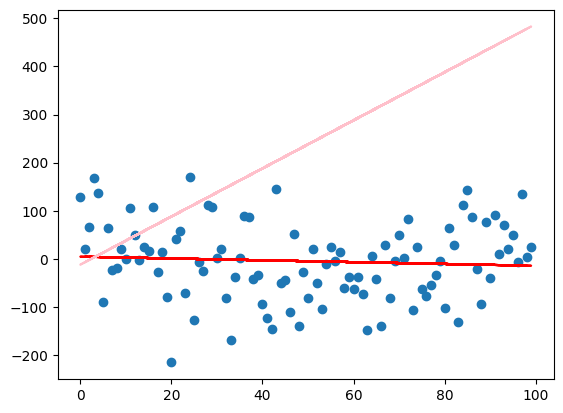

In [47]:
# La comparaison !!
pred_line = w_1[0,0] * x.reshape(-1)+ w_0[0]
plt.scatter(x.reshape(-1), data['y'])
plt.plot(x.reshape(-1), pred_line, c='r')
plt.plot(x.reshape(-1),5 * x - 12,c='pink')
plt.show()

In [48]:
# حساب نسبة الخطأ
from sklearn.metrics import mean_squared_error

ypred = model.predict(x)
print(f"MSE ERROR : {mean_squared_error(y, ypred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y, ypred))}")

MSE ERROR : 6453.189462199118
RMSE : 80.33174629123357


In [49]:
# مسابقة Kaggle !!!

# شوف فيديو 
#Machine Learning #5 || Linear Regression (2) Maths & Gradient Descent from Scratch || بالعربية


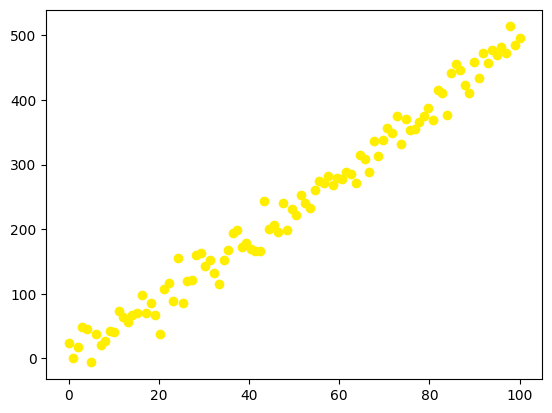

In [50]:
# Linear Regression Implement from scratch 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)
x = np.linspace(0,100,100)
y = 5 * x - 12
ry = np.random.normal(scale=20, size=y.shape[0]) +y

data = pd.DataFrame({'x':x, 'y': ry}).sample(frac=1).reset_index()[['index','y']].rename({'index': 'x'},axis=1)
plt.plot(x, ry,'o' ,c="#ffee00",  )
plt.show()

C:\Users\djabe\AppData\Local\Temp\ipykernel_7932\2335822251.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(y, 'r', c="#05cf53")


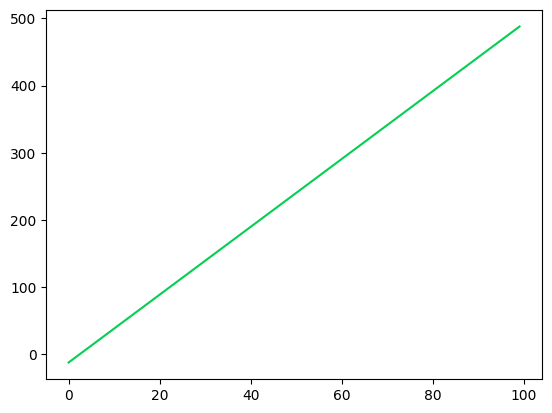

In [51]:
plt.plot(y, 'r', c="#05cf53")
plt.show()

In [52]:
data

,x,y
0,19,66.877681
1,6,37.304799
2,45,206.511241
3,57,281.928226
4,22,116.399835
...,...,...
95,13,56.090066
96,31,152.128907
97,85,455.210713
98,70,356.117165


In [53]:
# w1 = w
# w0 = b
w = 0.0
b = 0.0
alpha = 0.01
# الاكس عبارة عن مصفوفة 
for x in range(1000):
    dj_dw = np.mean((w * x + b - y) * x)
    dj_db = np.mean((w * x + b - y))
    loss = np.mean((w * x + b - y) ** 2)
    if x % 10 ==0:
        print(loss)
    w = w - alpha * dj_dw
    b = b - (alpha * dj_db)
    


77898.20875420877
22325.782815804472
21258.110792493615
100355032653602.52
8.536954002737016e+34
3.7293972593627935e+60
7.321620240279663e+89
1.4227219187297432e+122
9.668561524803321e+156
1.0719460059005403e+194
1.0809802397312195e+233
6.243040529062591e+273
inf
inf
inf
inf
inf
inf
inf
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


c:\Users\djabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\djabe\AppData\Local\Temp\ipykernel_7932\3117113256.py:10: RuntimeWarning: overflow encountered in square
  loss = np.mean((w * x + b - y) ** 2)
C:\Users\djabe\AppData\Local\Temp\ipykernel_7932\3117113256.py:8: RuntimeWarning: overflow encountered in multiply
  dj_dw = np.mean((w * x + b - y) * x)
C:\Users\djabe\AppData\Local\Temp\ipykernel_7932\3117113256.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - alpha * dj_dw
C:\Users\djabe\AppData\Local\Temp\ipykernel_7932\3117113256.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - (alpha * dj_db)


In [54]:
x = data.x.values
x = x / x.max()
y = data.y.values
print(x / x.max())

[0.19191919 0.06060606 0.45454545 0.57575758 0.22222222 0.25252525
 0.48484848 0.3030303  0.5959596  0.73737374 0.15151515 0.12121212
 0.49494949 0.95959596 0.14141414 0.50505051 0.8989899  0.42424242
 0.52525253 0.36363636 0.04040404 0.78787879 0.74747475 0.47474747
 0.68686869 0.17171717 0.83838384 0.08080808 0.16161616 0.88888889
 0.75757576 0.80808081 0.72727273 0.         0.05050505 0.60606061
 0.81818182 0.84848485 0.34343434 0.33333333 0.21212121 0.93939394
 0.07070707 0.66666667 0.94949495 0.98989899 0.96969697 0.63636364
 0.82828283 0.26262626 0.62626263 0.58585859 0.65656566 0.90909091
 0.55555556 0.09090909 0.39393939 0.77777778 0.86868687 0.29292929
 0.64646465 0.2020202  0.46464646 0.51515152 0.53535354 0.23232323
 0.27272727 0.02020202 0.28282828 0.37373737 0.87878788 0.1010101
 0.97979798 1.         0.43434343 0.6969697  0.61616162 0.35353535
 0.76767677 0.03030303 0.67676768 0.92929293 0.44444444 0.01010101
 0.38383838 0.11111111 0.91919192 0.54545455 0.4040404  0.18181

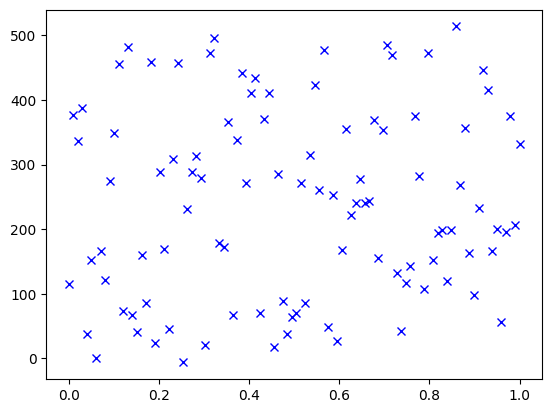

In [55]:
plt.plot(x, ry, 'bx')
plt.plot(x, w*x+b , 'r')